In [1]:
import os
import glob
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn import metrics
import tensorflow as tf
import tensorboard as tb
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
# !gdown IMAGE_DATASET_DRIVE_PATH
!gdown 1FOpBqxqZRkAkv1rlTPw1ZLME1wG_tJOv

!unzip "/content/clothing-dataset-small.zip"

Downloading...
From (original): https://drive.google.com/uc?id=1FOpBqxqZRkAkv1rlTPw1ZLME1wG_tJOv
From (redirected): https://drive.google.com/uc?id=1FOpBqxqZRkAkv1rlTPw1ZLME1wG_tJOv&confirm=t&uuid=2d07667c-f3bd-4cd6-a597-919e78925fee
To: /content/clothing-dataset-small.zip
100% 106M/106M [00:01<00:00, 67.4MB/s]
Archive:  /content/clothing-dataset-small.zip
   creating: clothing-dataset-small/
  inflating: clothing-dataset-small/.DS_Store  
   creating: clothing-dataset-small/test/
   creating: clothing-dataset-small/test/skirt/
  inflating: clothing-dataset-small/test/skirt/f4b934fc-e326-4f72-b535-53288b8b82d3.jpg  
  inflating: clothing-dataset-small/test/skirt/491982c3-3e90-431e-99e6-b14ecea36384.jpg  
  inflating: clothing-dataset-small/test/skirt/24963db3-649c-4f04-8da3-0375ede8e0a6.jpg  
  inflating: clothing-dataset-small/test/skirt/32b99302-cec7-4dec-adfa-3d4029674209.jpg  
  inflating: clothing-dataset-small/test/skirt/0558b2c5-be00-49de-b27f-8c88114ac36f.jpg  
  inflating: clot

In [3]:
# list all directories inside "train" folder
class_dirs = os.listdir("/content/clothing-dataset-small/train")
# dict to select one random image per class
imagePerClass = {}
# number of objects in each Class
countPerClass = {}

# list down all the classes in the folder
clsDirs = os.listdir("/content/clothing-dataset-small/train")

for cls in clsDirs:
  # get list of all the images per each class
  imgPaths = glob.glob(f"/content/clothing-dataset-small/train/{cls}/*")

  # gives the number of images per class
  countPerClass[cls] = len(imgPaths)

  # randomly selects an image and saves it in a dictionary
  randomImage = random.choice(imgPaths)
  imagePerClass[cls] = tf.keras.utils.load_img(randomImage)

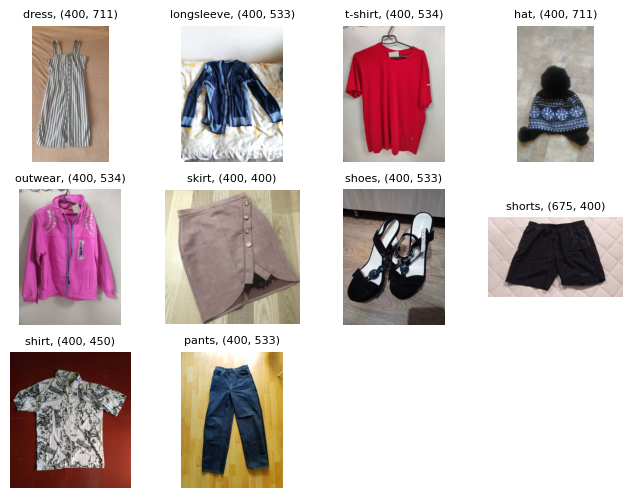

In [4]:
# display images
plt.figure(figsize=(8, 6))
for idx, (label, imgtoShow) in enumerate(imagePerClass.items()):
  # plot each Image
  ax = plt.subplot(3, 4, idx+1)
  plt.imshow(imgtoShow)
  plt.axis("off")
  plt.title(f"{label}, {imgtoShow.size}", fontsize=8)

Count of training samples per class:



Text(0, 0.5, 'Count')

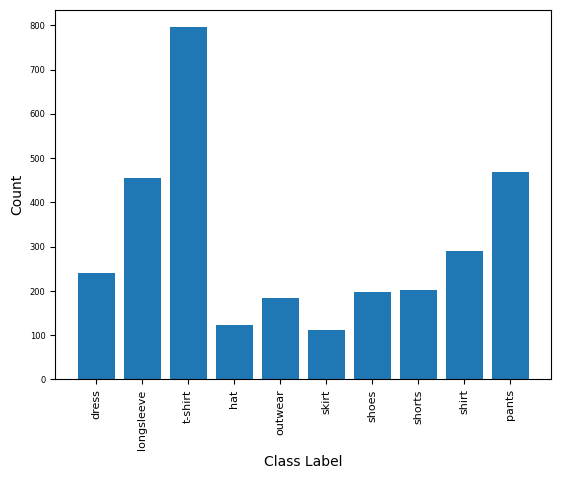

In [5]:
## Let's now Plot the Data Distribution of Training Data across Classes
print("Count of training samples per class:\n",)
countDataDist = pd.DataFrame({"label":countPerClass.keys(), "count":countPerClass.values()})
plt.bar(countDataDist["label"], countDataDist["count"])
plt.xlabel("Class Label", fontsize=10)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=6)
plt.ylabel("Count")

We can see that the class distribution is heavily imbalanced.
Ways to increase balance the data
* Under Sampling
* Over Sampling
* Fetch New Data
* Generate Synthetic Data using SMOTE (Not Prefered)
* Data Argumentation
* Synthetic data generation using Models like GANs

In [6]:
# loading the image Data set for Processing:
print('\nLoading Train Data...')
TrainData = tf.keras.utils.image_dataset_from_directory("/content/clothing-dataset-small/train", shuffle=True, label_mode="categorical")
ValData = tf.keras.utils.image_dataset_from_directory("/content/clothing-dataset-small/validation", shuffle=True, label_mode="categorical")
TestData = tf.keras.utils.image_dataset_from_directory("/content/clothing-dataset-small/test", shuffle=True,label_mode="categorical")


Loading Train Data...
Found 3068 files belonging to 10 classes.
Found 341 files belonging to 10 classes.
Found 372 files belonging to 10 classes.


In [7]:
# prepropcessing the Image Data:
height=128
width=128

data_preprocess = keras.Sequential(
    name="data_preprocess",
    layers=[
        layers.Resizing(height, width), # Shape Preprocessing
        layers.Rescaling(1.0/255), # Value Preprocessing
    ]
)


TrainData_prep = TrainData.map(lambda x, y: (data_preprocess(x), y))
ValData_prep = ValData.map(lambda x, y: (data_preprocess(x), y))
TestData_prep = TestData.map(lambda x, y: (data_preprocess(x), y))

In [8]:
num_classes = 10
hidden_size_1 = 1024
hidden_size_2 = 256

model = keras.Sequential(
    name="model_ann",
    layers=[
        layers.Flatten(input_shape=(height, width, 3)), # alternatively, input_shape=next(iter(train_ds))[0].shape[1:]
        layers.Dense(units=hidden_size_1, activation='relu'), # hidden layer 1
        layers.Dense(units=hidden_size_2, activation='relu'), # hidden layer 2
        layers.Dense(units=num_classes, activation='softmax'), # output layer
    ]
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
model.summary()

Model: "model_ann"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 49152)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1024)                │      50,332,672 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         262,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 50,597,642 (193.01 MB)

 Trainable params: 50,597,642 (193.01 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
modelchkPnt = tf.keras.callbacks.ModelCheckpoint(filepath="plane_ANN_2_layerModel.keras",
                                                 monitor="val_accuracy",
                                                 save_best_only=True,
                                                 save_weights_only=False)

lrScheduler = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_accuracy", factor=0.1)

earlyStopping = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True)

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

epochs = 10
model_fit = model.fit(TrainData_prep,
                      validation_data=ValData_prep,
                      epochs=epochs,
                      callbacks=[modelchkPnt, lrScheduler, earlyStopping])

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 16s 134ms/step - accuracy: 0.1841 - loss: 30.6169 - val_accuracy: 0.3226 - val_loss: 3.7884 - learning_rate: 0.0010
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 18s 124ms/step - accuracy: 0.3123 - loss: 3.1056 - val_accuracy: 0.3460 - val_loss: 2.7612 - learning_rate: 0.0010
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 15s 64ms/step - accuracy: 0.3630 - loss: 2.2524 - val_accuracy: 0.3284 - val_loss: 2.4682 - learning_rate: 0.0010
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - accuracy: 0.3990 - loss: 1.9936 - val_accuracy: 0.3812 - val_loss: 2.0110 - learning_rate: 0.0010
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 16s 55ms/step - accuracy: 0.4446 - loss: 1.7288 - val_accuracy: 0.3402 - val_loss: 2.4065 - learning_rate: 0.0010
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 11s 115ms/step - accuracy: 0.4474 - loss: 1.7393 - val_accuracy: 0.3930 - val_loss: 1.8089 - learning_rate: 0.0010
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.4886 - loss: 1.5

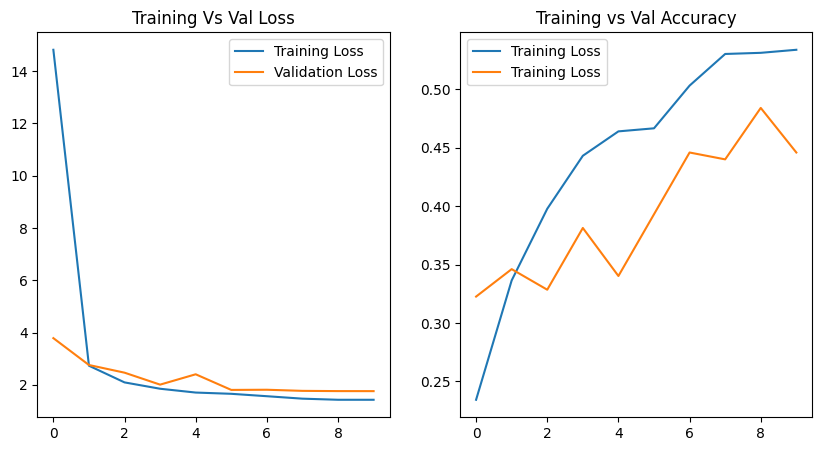

In [11]:
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(10, 5))
ax[0].plot(model_fit.history["loss"], label="Training Loss")
ax[0].plot(model_fit.history["val_loss"], label="Validation Loss")
ax[0].legend()
ax[0].set_title("Training Vs Val Loss")

ax[1].plot(model_fit.history["accuracy"], label="Training Loss")
ax[1].plot(model_fit.history["val_accuracy"], label="Training Loss")
ax[1].legend()
ax[1].set_title("Training vs Val Accuracy")

plt.show()

We can see that, not much improvement/reduction in Training and validation Loss is seen in ANN based model

In [12]:
modelPreds = model.predict(TestData_prep)

# Predicted Labels
predictedLabels = np.argmax(modelPreds, axis=1)

# True Labels
trueLabels = tf.concat([np.argmax(y, axis=1) for x, y in TestData_prep], axis=0)
testImages = tf.concat([x for x, y in TestData_prep], axis=0)

# Test Accuracy
accScore = metrics.accuracy_score(predictedLabels, trueLabels)
print("Test Accuracy = ", accScore)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step
Test Accuracy =  0.13978495


Accuracy is Pretty Low.

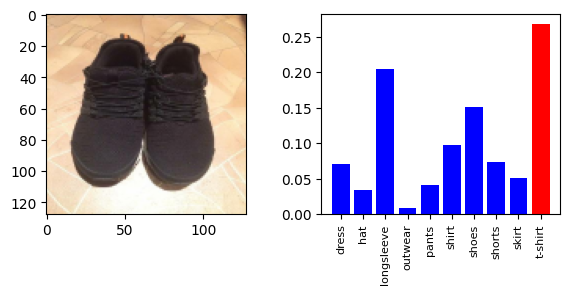

In [13]:
clrs = ["red" if x == max(modelPreds[1]) else "blue" for x in modelPreds[1]]

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(6, 3))
ax[0].imshow(testImages[1])
ax[1].bar(TestData.class_names, modelPreds[1], color=clrs)
for tick in ax[1].get_xticklabels():
    tick.set_rotation(90)
    tick.set_fontsize(8)
plt.tight_layout()
plt.show()

## Same with Convolution Neural Nets

In [14]:
inpLayer = tf.keras.layers.Input(shape=(height, width, 3))
convlayer = tf.keras.layers.Conv2D(filters=64, kernel_size=(3, 3), activation="relu") (inpLayer)
mxPool = tf.keras.layers.MaxPooling2D(pool_size=(2, 2)) (convlayer)
flatten = tf.keras.layers.Flatten() (mxPool)
dense1 = tf.keras.layers.Dense(units=256, activation="relu") (flatten)
outLayer = tf.keras.layers.Dense(units=10, activation="softmax") (dense1)

model_basic_CNN = tf.keras.Model(inputs=inpLayer, outputs=outLayer)

In [15]:
model_basic_CNN.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 126, 126, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 254016)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 256)                 │      65,028,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 65,032,714 (248.08 MB)

 Trainable params: 65,032,714 (248.08 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
modelchkPnt = tf.keras.callbacks.ModelCheckpoint(filepath="plane_CNN_1_CNV_1_Dense.keras",
                                                 monitor="val_accuracy",
                                                 save_best_only=True,
                                                 save_weights_only=False,
                                                 )

lrScheduler = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_accuracy", factor=0.1)

earlyStopping = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True)

model_basic_CNN.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

epochs = 10
model_fit = model_basic_CNN.fit(TrainData_prep,
                                validation_data=ValData_prep,
                                epochs=epochs,
                                callbacks=[modelchkPnt, lrScheduler, earlyStopping])

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 23s 197ms/step - accuracy: 0.2299 - loss: 10.9078 - val_accuracy: 0.4839 - val_loss: 1.6406 - learning_rate: 0.0010
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 31s 120ms/step - accuracy: 0.5604 - loss: 1.3861 - val_accuracy: 0.5630 - val_loss: 1.4346 - learning_rate: 0.0010
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 11s 120ms/step - accuracy: 0.7872 - loss: 0.7282 - val_accuracy: 0.5777 - val_loss: 1.4445 - learning_rate: 0.0010
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 20s 116ms/step - accuracy: 0.9148 - loss: 0.3404 - val_accuracy: 0.5865 - val_loss: 1.4666 - learning_rate: 0.0010
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 20s 111ms/step - accuracy: 0.9687 - loss: 0.1520 - val_accuracy: 0.6129 - val_loss: 1.6375 - learning_rate: 0.0010
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 16s 62ms/step - accuracy: 0.9931 - loss: 0.0674 - val_accuracy: 0.6041 - val_loss: 1.6912 - learning_rate: 0.0010
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 13s 132ms/step - accuracy: 0.9962 - loss: 0.

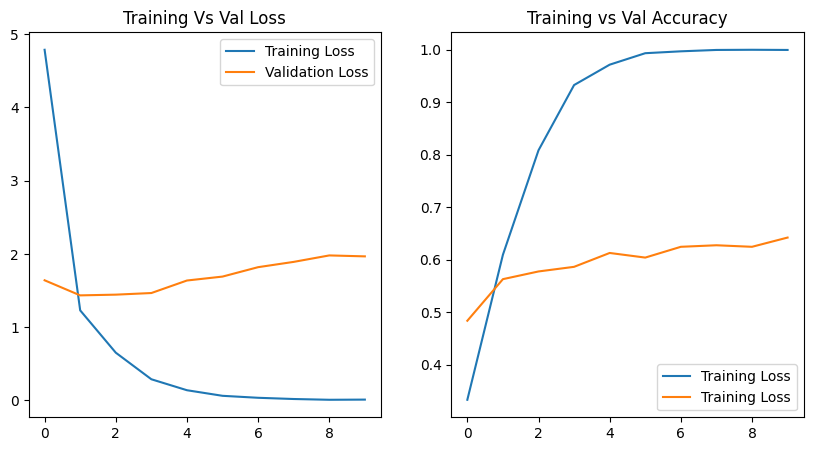

In [17]:
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(10, 5))
ax[0].plot(model_fit.history["loss"], label="Training Loss")
ax[0].plot(model_fit.history["val_loss"], label="Validation Loss")
ax[0].legend()
ax[0].set_title("Training Vs Val Loss")

ax[1].plot(model_fit.history["accuracy"], label="Training Loss")
ax[1].plot(model_fit.history["val_accuracy"], label="Training Loss")
ax[1].legend()
ax[1].set_title("Training vs Val Accuracy")

plt.show()

In [23]:
modelPreds = model_basic_CNN.predict(TestData_prep)

# Predicted Labels
predictedLabels = np.argmax(modelPreds, axis=1)

# True Labels
trueLabels = tf.concat([np.argmax(y, axis=1) for x, y in TestData_prep], axis=0)
testImages = tf.concat([x for x, y in TestData_prep], axis=0)

# Test Accuracy
accScore = metrics.accuracy_score(predictedLabels, trueLabels)
print("Test Accuracy = ", accScore)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step
Test Accuracy =  0.15053763440860216
